# In Depth: Principal Component Analysis

PCA is fundamentally a dimensionality reduction algorithm.

Other uses:
- Noise filtering
- Feature exraction and engineering

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
from sklearn.preprocessing import StandardScaler

## Introducing Principal Component Analysis

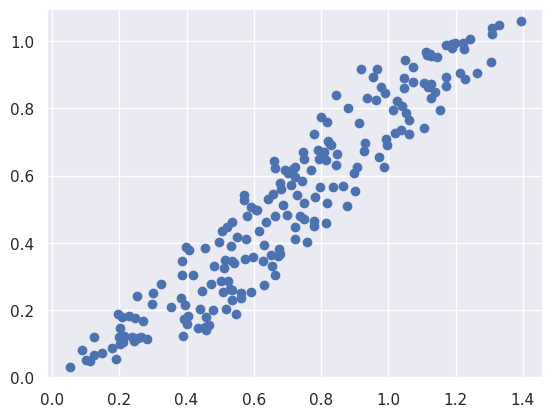

In [20]:
rng = np.random.default_rng(seed=1)
X = np.dot(rng.random((2, 2)), rng.random((2, 200))).T
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal')
plt.show()

This looks a problem that could be solved with linear regression. But that's not the problem at hand.

Instead of attempting to predict $y$ values from $x$ values, we attempt to find a *relationship* between $x$ and $y$. And unsupervised learning can be used for this.

In Principal component analysis, we can quantify this relationship by finding a list of the **principal axes** in the data, and using these axes the describe the data.

In [21]:
from sklearn.decomposition import PCA
pca_model = PCA(n_components=2)
pca_model.fit(X)

PCA(n_components=2)

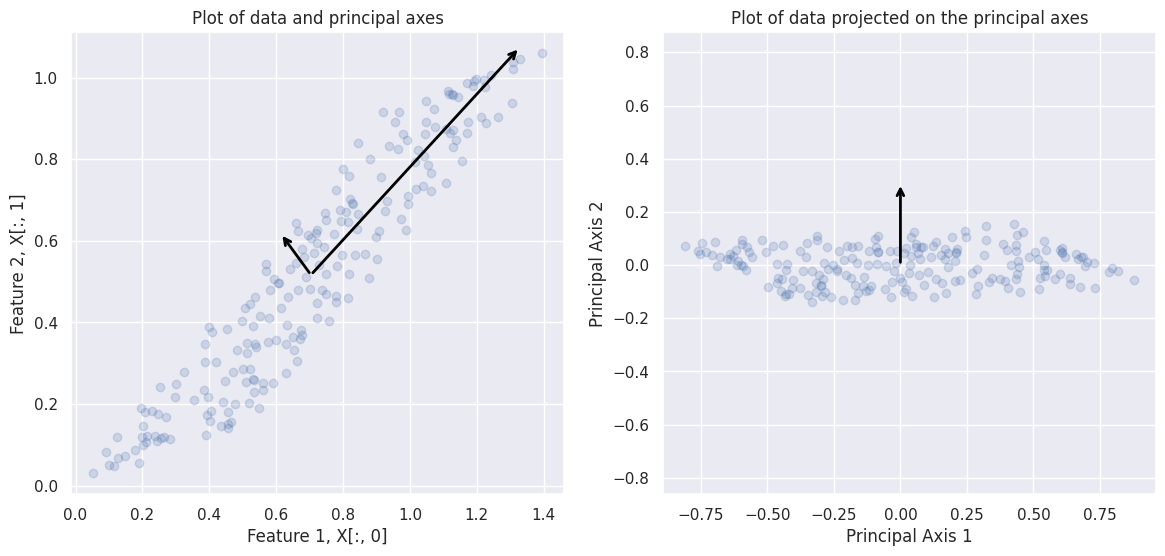

In [22]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops = dict(arrowstyle='->',
                     linewidth=2,
                     color = 'black')
    ax.annotate('', v1, v0, arrowprops=arrowprops)

fig, ax = plt.subplots(1,2,figsize=(14,6))
ax[0].scatter(X[:,0], X[:,1], alpha=0.2)
for length, vector in zip(pca_model.explained_variance_, pca_model.components_):
    v = vector * np.sqrt(length) * 2 #Scaled up by 2 so it looks better
    draw_vector(pca_model.mean_, pca_model.mean_ + v, ax=ax[0])
ax[0].set_title('Plot of data and principal axes')
ax[0].set_xlabel('Feature 1, X[:, 0]')
ax[0].set_ylabel('Feature 2, X[:, 1]')

X_transform = pca_model.transform(X)
ax[1].scatter(X_transform[:, 0], X_transform[:, 1], alpha=0.2)
arrowprops = dict(arrowstyle='->', linewidth=2, color='black')
ax[1].annotate('',(0,2 * X_transform[:,1].max()), (0,0), arrowprops=arrowprops)
ax[1].annotate('',(2 * X_transform[:,0].max(),0), (0,0), arrowprops=arrowprops)
ax[1].set_title('Plot of data projected on the principal axes')
ax[1].set_xlabel('Principal Axis 1')
ax[1].set_ylabel('Principal Axis 2')

plt.axis('equal')
plt.show()

- The vectors represent the **principal axes** of the data -- these are the directions along which the features vary the most.
- The length of each vector indicate how the data varies along that direction; conequently, it measures the importance of a feature.
- The projected data are called the **principal components** of the data

We can already see here that the second feature varies. And this is why PCA is a technique for dimensionality reduction -- it makes sense to just drop the second principal component because it has relatively low variance.

### PCA as a dimensionality reduction technique

In [23]:
X_transformed = PCA(n_components=1).fit_transform(X)
print('original shape:', X.shape)
print('transformed shape:', X_transformed.shape)

original shape: (200, 2)
transformed shape: (200, 1)


Once we drop the second component, we can rotate the data back and project it back on the feature space

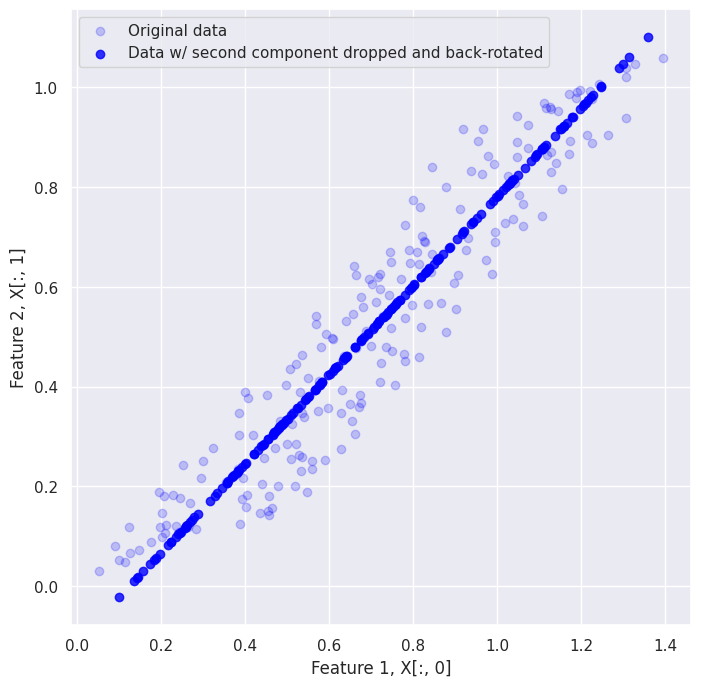

In [24]:
X_new = PCA(n_components=1).fit(X).inverse_transform(X_transformed)
fig = plt.figure(figsize=(8,8))
plt.scatter(X[:,0], X[:,1], alpha=0.2, c='blue', label='Original data')
plt.scatter(X_new[:,0], X_new[:,1], alpha=0.8, c='blue', label='Data w/ second component dropped and back-rotated')
plt.xlabel('Feature 1, X[:, 0]')
plt.ylabel('Feature 2, X[:, 1]')
plt.legend()
plt.show()

PCA as a dimensionality reduction technique means the information along the least important axes is removed, leaving only the components with the highest variance.

### PCA for visualization: Handwritten digits


In [34]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

pca = PCA(n_components=64)
pca.fit(X)

PCA(n_components=64)

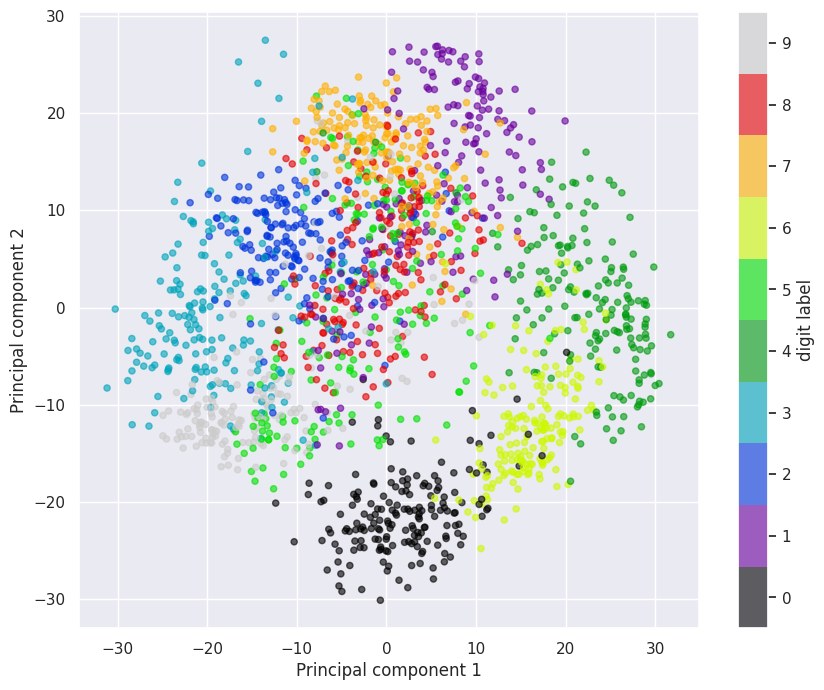

In [35]:
pca = PCA(n_components=2).fit(X)
X_transform = pca.transform(X) #Projected onto the 2 principal components

fig = plt.figure(figsize=(10,8))
plt.scatter(X_transform[:,0], X_transform[:,1], c=y, cmap=plt.get_cmap('nipy_spectral', 10), s=20, alpha=0.6)
plt.colorbar(label='digit label', ticks=range(10))
plt.clim(-0.5,9.5)

plt.xlabel('Principal component 1')
plt.ylabel('Principal component 2')
plt.show()

In [36]:
import plotly.express as px

pca = PCA(n_components = 3).fit(X)
X_transform = pca.transform(X)

# Create interactive 3D scatter plot
fig = px.scatter_3d(x=X_transform[:,0], y=X_transform[:,1], z=X_transform[:,2],
                    opacity=0.7, color=y.astype(str), color_discrete_sequence = px.colors.qualitative.Plotly)

fig.update_traces(marker=dict(size=5, line=dict(width=.25)), showlegend=True)
fig.update_layout(coloraxis_showscale=True, width=1000, height=800, scene=dict(
        xaxis=dict(title='Principal component 1'),
        yaxis=dict(title='Principal component 2'),
        zaxis=dict(title='Principal component 3')
    ))

fig.show()


We can see that the 9 types of digits separate quite well in either of these two or three dimensional spaces.

By including the third component, we can see the separation between the 5's and 8's better; but not so much. Quantitatively, including the third component makes a better model as its explained variance is at the same level as the first and second components.

The downside of this technique is that the components are not very easy to interpret. The above 2 and 3 dimensional projections is not the feature space. The components are combinations of features.

### What do the components mean?


In the above image data, an image can be thought of as a linear combination of pixel vectors. So, the value of the j-th feature is the coefficient of pixel j in the linear combination.

$$ \text{image } i = a_{i,0} \cdot (\textbf{pixel }\mathbf{1}) + a_{i,1} \cdot (\textbf{pixel }\mathbf{2}) + \cdots + a_{i,j} \cdot (\textbf{pixel }\mathbf{j}) + \cdots + a_{i,64} \cdot (\textbf{pixel }\mathbf{64})$$

This is just one set of basis vectors to represent an image. PCA can be thought of as finding the optimal set of basis vectors for the data.
For instance, by applying PCA with 8 principal components, we'll get something like

$$ \text{image } i = b_{i,0} \cdot (\textbf{PC }\mathbf{1}) + b_{i,1} \cdot (\textbf{PC }\mathbf{2}) + \cdots + b_{i,j} \cdot (\textbf{PC }\mathbf{j}) + \cdots + b_{i,8} \cdot (\textbf{PC }\mathbf{8})$$

Here, the vectors $\textbf{PC }\mathbf{1},\, \textbf{PC }\mathbf{2},\,\dots,\,\textbf{PC }\mathbf{8}$ are the principal components of the image, and each of these vectors can be represented as the sum of the mean and the linear combinations of the 64 pixels.

In [73]:
pca = PCA(n_components=8)
pca.fit(X)

PCA(n_components=8)

In [74]:
pca.components_[0]

array([ 0.00000000e+00, -1.73094651e-02, -2.23428835e-01, -1.35913304e-01,
       -3.30323092e-02, -9.66340844e-02, -8.32943805e-03,  2.26900082e-03,
       -3.20516495e-04, -1.19308905e-01, -2.44451676e-01,  1.48512745e-01,
       -4.67319410e-02, -2.17740744e-01, -1.48136776e-02,  4.47779518e-03,
       -4.94136398e-05, -7.95419375e-02,  8.33951454e-02,  2.15915342e-01,
       -1.72126801e-01, -1.63712098e-01,  2.86444452e-02,  4.23251803e-03,
        9.85488574e-05,  6.42319144e-02,  2.54093316e-01, -3.56771026e-02,
       -2.09462569e-01, -4.31311420e-02,  5.13118688e-02,  2.13422732e-04,
        0.00000000e+00,  1.59950883e-01,  3.68690774e-01,  1.64406827e-01,
        8.52007908e-02,  3.72982855e-02,  2.15866980e-02,  0.00000000e+00,
        1.28865585e-03,  1.06945287e-01,  3.03067457e-01,  2.47813041e-01,
        2.09637296e-01,  1.22325219e-02, -3.69458497e-02,  1.61485028e-03,
        6.93023548e-04, -8.35144239e-03, -5.58598986e-02,  9.30534169e-02,
        1.07387720e-01, -

In [75]:
X_transform = pca.transform(X)

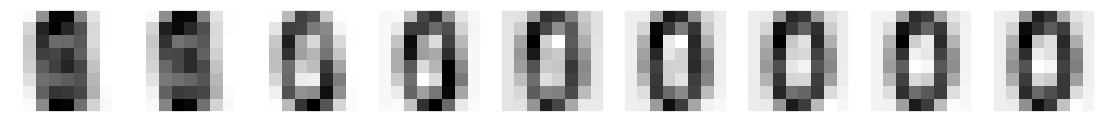

In [76]:
sample = X_transform[0]
mean = pca.mean_.reshape(8,8)
components = pca.components_.reshape(8,8,8)

fig, ax = plt.subplots(1,9,figsize=(14,2),
                       subplot_kw=dict(xticks=[], yticks=[]))

ax[0].imshow(mean, cmap='binary')

comb = mean
for i, component in enumerate(components):
  comb += sample[i] * component
  ax[i+1].imshow(comb, cmap='binary')

plt.show()